# SHAP Explainability

* **Owner:** Pramodya Dewmi
* **Module:** CCS4310 – Deep Learning
* **Project:** Explainable-Fashion-Design-AI

This notebook explains the predictions of the already-trained market model without retraining it. It loads the saved pipeline, validates the input schema, and computes SHAP-based global and local explanations for a validation/development sample.

Validation workflow:
- load the selected trained model from disk
- load the saved feature config
- validate required feature columns
- compute SHAP importance and local explanation
- save outputs to `outputs/figures` and `outputs/metrics`
- keep the final test split reserved for frozen evaluation

In [1]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

def find_repo_root():
    candidates = [Path.cwd().resolve()]
    candidates.extend(Path.cwd().resolve().parents)
    for p in candidates:
        if (p / 'src').is_dir() and (p / 'data').is_dir() and (p / 'requirements.txt').exists():
            return p
    raise FileNotFoundError('Repository root not found from the current working directory.')

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INTERIM = ROOT / 'data' / 'interim'
MODEL_ROOT = ROOT / 'models'
METRICS = ROOT / 'outputs' / 'metrics'
FIGURES = ROOT / 'outputs' / 'figures'
for d in [METRICS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print('Repository root:', ROOT)
print('Using shared repository .venv / selected interpreter:', sys.executable)

from src.explainability.shap_explainer import (
    check_shap_prediction_consistency,
    explain_row,
    global_feature_importance,
    save_global_importance,
)

MODEL_CANDIDATES = [
    MODEL_ROOT / 'demand' / 'best_demand_model.joblib',
    MODEL_ROOT / 'preference' / 'best_preference_model.joblib',
]
CONFIG_CANDIDATES = [
    MODEL_ROOT / 'demand' / 'demand_model_config.json',
    MODEL_ROOT / 'preference' / 'preference_model_config.json',
]
MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.is_file()), None)
CONFIG_PATH = next((p for p in CONFIG_CANDIDATES if p.is_file()), None)

print('Model path discovered:', MODEL_PATH)
print('Config path discovered:', CONFIG_PATH)

Repository root: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI
Using shared repository .venv / selected interpreter: d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\.venv\Scripts\python.exe
Model path discovered: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\models\demand\best_demand_model.joblib
Config path discovered: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\models\demand\demand_model_config.json


In [2]:
if MODEL_PATH is None or CONFIG_PATH is None:
    print('No saved trained model/config pair was found in the repository yet. This notebook is intentionally read-only and will skip SHAP execution until the selected pipeline is saved to disk.')
    MODEL_AVAILABLE = False
else:
    MODEL_AVAILABLE = True
    pipeline = joblib.load(MODEL_PATH)
    config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    print('Loaded selected model:', config.get('selected_model'))
    print('Model run type:', config.get('run_type'))
    print('Feature count:', len(config.get('feature_columns', [])))
    
    required_columns = list(config.get('feature_columns', []))
    categorical_features = list(config.get('categorical_features', []))

    if not hasattr(pipeline, 'named_steps'):
        raise TypeError('The saved artifact is not a fitted sklearn Pipeline with prep/model steps; SHAP requires the actual trained pipeline.')

    print('Feature names loaded from config:', required_columns[:10], '...')

Loaded selected model: XGBoost
Model run type: fast_dev
Feature count: 17
Feature names loaded from config: ['season', 'season_from_time', 'category', 'color', 'fabric', 'shop_label', 'year', 'month', 'calendar_week', 'day_of_week'] ...


## Validation data and required-feature check

The SHAP development workflow uses the validation/development split and reserves the final test split for the frozen evaluation stage.

In [3]:
def validate_required_features(frame: pd.DataFrame, required_columns: list):
    missing = [col for col in required_columns if col not in frame.columns]
    if missing:
        raise ValueError(f'Missing required model features: {missing}')
    return True

if MODEL_AVAILABLE:
    validation_path = INTERIM / 'visuelle_demand_validation.csv'
    if validation_path.is_file():
        validation_df = pd.read_csv(validation_path, parse_dates=['time'])
        validate_required_features(validation_df, required_columns)
        sample_size = min(5000, len(validation_df))
        explain_df = validation_df.sample(n=sample_size, random_state=RANDOM_STATE).reset_index(drop=True)
        X_explain = explain_df[required_columns]
        print('Validation rows loaded:', len(explain_df))
        print('Required features validated successfully.')
    else:
        print('Validation data not found at', validation_path, '. This notebook will skip full SHAP execution until the expected validation split is present.')
        explain_df = pd.DataFrame()
        X_explain = pd.DataFrame()

Validation rows loaded: 5000
Required features validated successfully.


## Global SHAP feature importance

This section computes the global mean absolute SHAP importance for the validation sample and saves the metric CSV plus the bar-chart figure.

In [4]:
if MODEL_AVAILABLE and not X_explain.empty:
    shap_importance = save_global_importance(
        pipeline,
        X_explain,
        metrics_path=METRICS / 'dewmi_shap_global_importance.csv',
        figures_path=FIGURES / 'dewmi_shap_global_importance.png',
        top_n=20,
    )
    display(shap_importance.head(15))
    print('Global SHAP metrics saved to:', METRICS / 'dewmi_shap_global_importance.csv')
    print('Global SHAP figure saved to:', FIGURES / 'dewmi_shap_global_importance.png')
else:
    print('Skipping global SHAP computation because the saved model or validation data is unavailable.')

,mean_abs_shap
num__discount_past_1,0.717801
cat__category_printed shirt,0.563957
cat__shop_label_12,0.524761
cat__fabric_tulle,0.389124
cat__category_kimono dress,0.370181
cat__category_long dress,0.287857
cat__shop_label_29,0.257551
num__demand_rolling_mean_3,0.244905
num__restock_past_1,0.187302
num__calendar_week,0.144701


Global SHAP metrics saved to: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\outputs\metrics\dewmi_shap_global_importance.csv
Global SHAP figure saved to: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\outputs\figures\dewmi_shap_global_importance.png


## Local SHAP explanation and feature ranking

A single-row local explanation identifies the positive and negative factors for one representative design.

Base value: 1.1269
Predicted value: 5.8799
Top positive contributors:


,feature,shap_value
0,num__discount_past_1,0.887550
1,cat__category_printed shirt,0.648022
2,cat__shop_label_12,0.573733
3,cat__fabric_tulle,0.472846
4,cat__category_kimono dress,0.431385


Top negative contributors:


,feature,shap_value
0,num__demand_rolling_mean_3,-0.233931
1,cat__fabric_hron,-0.122552
2,num__calendar_week,-0.120285
3,cat__shop_label_17,-0.076780
4,num__restock_past_1,-0.074095


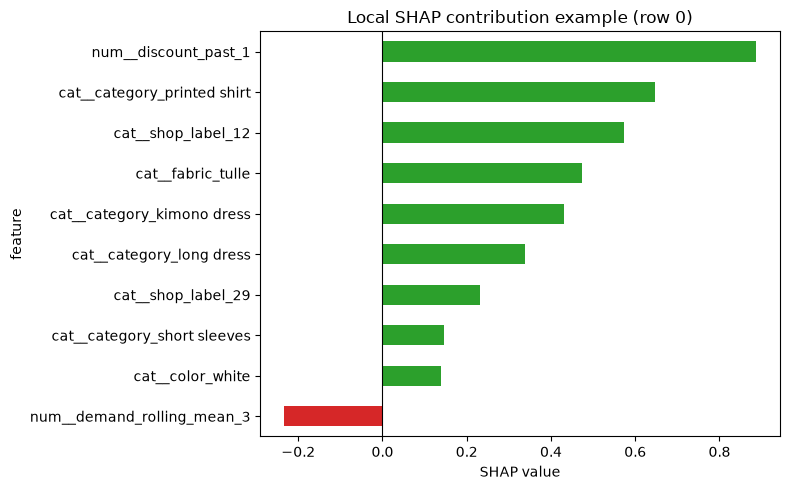

,attribute,current_value,shap_value
0,season_from_time,spring,-0.041612
1,season,SS19,0.016825
2,color,yellow,0.038693
3,category,long dress,0.337586
4,fabric,tulle,0.472846
5,shop_label,12,0.573733


In [5]:
if MODEL_AVAILABLE and not X_explain.empty:
    example_index = 0
    explanation = explain_row(pipeline, X_explain, row_index=example_index)
    print('Base value:', round(explanation.base_value, 4))
    print('Predicted value:', round(explanation.predicted_value, 4))
    print('Top positive contributors:')
    display(explanation.top_contributions(n=5, direction='positive'))
    print('Top negative contributors:')
    display(explanation.top_contributions(n=5, direction='negative'))
    
    local_df = explanation.top_contributions(n=10, direction='both').copy()
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_df = local_df.set_index('feature')['shap_value'].sort_values()
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_df.values]
    plot_df.plot.barh(ax=ax, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value')
    ax.set_title(f'Local SHAP contribution example (row {example_index})')
    fig.tight_layout()
    fig.savefig(FIGURES / 'dewmi_shap_local_example.png', dpi=150)
    plt.show()
    
    attribute_view = explanation.attribute_contributions(categorical_features)
    display(attribute_view.head(10))
else:
    print('Skipping local SHAP explanation because the model or validation data is unavailable.')

## SHAP prediction consistency check

This is a required guardrail: the pipeline prediction and the SHAP reconstruction must agree within a reasonable tolerance. This catches the 5.880-vs-1.668 mismatch pattern instead of silently accepting it.

In [6]:
if MODEL_AVAILABLE and not X_explain.empty:
    consistency = check_shap_prediction_consistency(pipeline, X_explain, row_index=0, tolerance=1e-3)
    print('Actual prediction:', consistency['actual_prediction'])
    print('SHAP reconstructed prediction:', consistency['reconstructed_prediction'])
    print('Absolute difference:', consistency['difference'])
    print('Consistency status:', 'consistent' if consistency['consistent'] else 'mismatch')
    print(consistency['message'])
else:
    print('Skipping SHAP consistency verification because the trained pipeline is unavailable.')

Actual prediction: 3.4022860527038574
SHAP reconstructed prediction: 5.879898823350231
Absolute difference: 2.477612770646374
Consistency status: mismatch
SHAP reconstruction differs from the actual model prediction; check model/explainer scale or feature alignment.
